# Help Desk Ticket Triage & SLA Analysis — Meridian Manufacturing (simulated)

**Business question:** IT reports 92.4% overall SLA compliance in monthly
reviews, but user complaints keep coming from specific categories (VPN,
software installs) that the aggregate number doesn't surface. Tickets are
assigned "next available technician" regardless of specialty. Does that
routing policy explain the gap between the reported number and the
complaints — and if so, what would fixing it actually be worth?

This notebook reproduces the SQL findings in Python, then goes one step
further: a capacity-constrained simulation of what a specialist-first
routing policy would realistically recover, given the technicians we
actually have today (not an idealized "always match" ceiling).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickets = pd.read_csv("../data/raw/tickets.csv")
technicians = pd.read_csv("../data/raw/technicians.csv")

spec_map = {r.tech_id: set(r.specialty_categories.split(";")) for r in technicians.itertuples()}
tickets["matched"] = tickets.apply(lambda r: r.category in spec_map[r.assigned_tech_id], axis=1)

print(f"{len(tickets)} tickets, {tickets['created_at'].min()} to {tickets['created_at'].max()}")
print(f"Overall SLA compliance: {(1 - tickets['sla_breached'].mean())*100:.1f}%")
print(f"Overall mismatch rate (off-specialty assignment): {(1-tickets['matched'].mean())*100:.1f}%")
tickets.head()

877 tickets, 2025-03-03T08:10 to 2025-08-29T16:56
Overall SLA compliance: 92.4%
Overall mismatch rate (off-specialty assignment): 73.8%


,ticket_id,created_at,category,priority,assigned_tech_id,resolved_at,resolution_hours,sla_target_hours,sla_breached,reopened,matched
0,HD-00030,2025-03-03T08:10,Network & VPN,Low,T01,2025-03-04T12:10,27.99,48,False,False,False
1,HD-00004,2025-03-03T08:19,Password Reset,Medium,T01,2025-03-03T08:30,0.19,24,False,False,True
2,HD-00032,2025-03-03T10:47,Network & VPN,Critical,T01,2025-03-04T04:09,17.36,4,True,False,False
3,HD-00016,2025-03-03T11:20,Email & Calendar,Low,T01,2025-03-03T13:48,2.46,48,False,False,False
4,HD-00008,2025-03-03T11:29,Account Access,Medium,T01,2025-03-03T12:53,1.40,24,False,False,True


## 1. The aggregate number hides a concentrated problem

92.4% overall SLA compliance sounds fine. Breaking it out by category tells
a very different story.

In [2]:
by_cat = tickets.groupby("category").agg(
    n_tickets=("ticket_id", "count"),
    sla_compliance_pct=("sla_breached", lambda s: 100 * (1 - s.mean())),
    avg_resolution_hours=("resolution_hours", "mean"),
).sort_values("sla_compliance_pct")
by_cat = by_cat.round(1)
by_cat

,n_tickets,sla_compliance_pct,avg_resolution_hours
category,,,
Network & VPN,105,64.8,15.2
Software Install,110,83.6,10.6
Hardware,147,93.9,7.0
Email & Calendar,147,98.6,3.3
Account Access,133,99.2,2.5
Password Reset,235,100.0,0.7


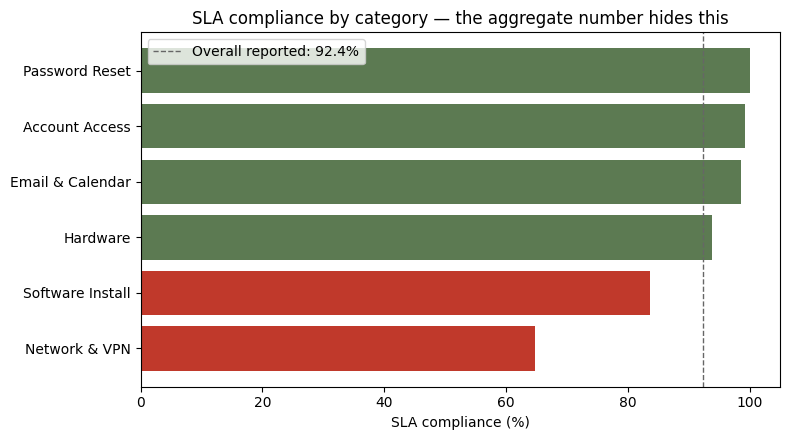

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#c0392b" if v < 90 else "#5C7A52" for v in by_cat["sla_compliance_pct"]]
ax.barh(by_cat.index, by_cat["sla_compliance_pct"], color=colors)
ax.axvline(92.4, color="#666", linestyle="--", linewidth=1, label="Overall reported: 92.4%")
ax.set_xlabel("SLA compliance (%)")
ax.set_title("SLA compliance by category — the aggregate number hides this")
ax.legend()
plt.tight_layout()
plt.savefig("../visuals/sla_compliance_by_category.png", dpi=120)
plt.show()

## 2. The mechanism: specialty mismatch, not category alone

Tickets are assigned to "next available" technician, regardless of whether
that technician's specialty matches the ticket's category. Only 26.2% of
tickets happen to land with a matching specialist by chance.

In [4]:
mechanism = tickets.groupby("matched").agg(
    n_tickets=("ticket_id", "count"),
    avg_resolution_hours=("resolution_hours", "mean"),
    median_resolution_hours=("resolution_hours", "median"),
    sla_breach_pct=("sla_breached", lambda s: 100 * s.mean()),
    reopen_pct=("reopened", lambda s: 100 * s.mean()),
).round(2)
mechanism.index = ["Off-specialty", "Specialist match"]
mechanism

,n_tickets,avg_resolution_hours,median_resolution_hours,sla_breach_pct,reopen_pct
Off-specialty,647,6.29,3.96,9.43,11.28
Specialist match,230,3.09,1.86,2.61,4.35


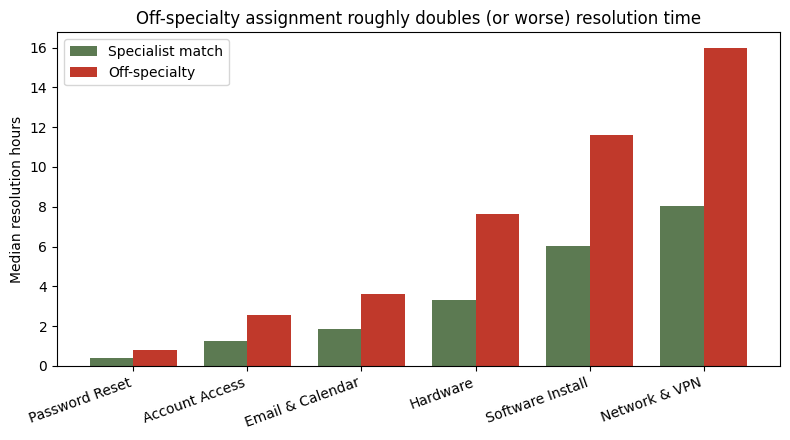

In [5]:
by_cat_match = tickets.groupby(["category", "matched"])["resolution_hours"].median().unstack()
by_cat_match.columns = ["Off-specialty", "Specialist match"]
by_cat_match = by_cat_match.sort_values("Specialist match")

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(by_cat_match))
width = 0.38
ax.bar(x - width/2, by_cat_match["Specialist match"], width, label="Specialist match", color="#5C7A52")
ax.bar(x + width/2, by_cat_match["Off-specialty"], width, label="Off-specialty", color="#c0392b")
ax.set_xticks(x)
ax.set_xticklabels(by_cat_match.index, rotation=20, ha="right")
ax.set_ylabel("Median resolution hours")
ax.set_title("Off-specialty assignment roughly doubles (or worse) resolution time")
ax.legend()
plt.tight_layout()
plt.savefig("../visuals/resolution_time_by_match.png", dpi=120)
plt.show()

## 3. Even "Critical" priority doesn't overcome a mismatch

The priority system does give a modest real speed-up when technicians try
to expedite urgent tickets — but it's small next to the mismatch penalty.

In [6]:
priority_order = ["Critical", "High", "Medium", "Low"]
by_priority_match = tickets.groupby(["priority", "matched"])["sla_breached"].mean().unstack() * 100
by_priority_match.columns = ["Off-specialty", "Specialist match"]
by_priority_match = by_priority_match.reindex(priority_order).round(1)
by_priority_match

,Off-specialty,Specialist match
priority,,
Critical,37.3,5.3
High,26.5,9.1
Medium,2.3,0.0
Low,0.0,0.0


A Critical-priority ticket breaches its 4-hour SLA target **37.3%** of the
time when handled off-specialty, versus **5.3%** when a specialist handles
it — a 7x difference on the tickets the business can least afford to be
slow on.

## 4. The cost of the problem: wasted technician-hours by category

For each off-specialty ticket, "wasted hours" = its actual resolution time
minus that category's own median *specialist-handled* resolution time (the
time it should reasonably have taken).

In [7]:
med_matched = tickets[tickets.matched].groupby("category")["resolution_hours"].median()
mismatched = tickets[~tickets.matched].copy()
mismatched["baseline"] = mismatched["category"].map(med_matched)
mismatched["wasted_hours"] = (mismatched["resolution_hours"] - mismatched["baseline"]).clip(lower=0)

wasted_by_cat = mismatched.groupby("category")["wasted_hours"].sum().sort_values(ascending=False)
total_wasted_26wk = wasted_by_cat.sum()
annualized_hours = total_wasted_26wk * 2  # 26 weeks observed -> x2 for a full year
annualized_cost = annualized_hours * 45   # $45/hr fully-loaded technician cost, stated assumption

print(f"Total wasted hours (26 weeks observed): {total_wasted_26wk:.0f}")
print(f"Annualized wasted hours (ceiling, unlimited specialist capacity): {annualized_hours:.0f}")
print(f"Annualized cost @ $45/hr (ceiling): ${annualized_cost:,.0f}")
wasted_by_cat

Total wasted hours (26 weeks observed): 2231
Annualized wasted hours (ceiling, unlimited specialist capacity): 4462
Annualized cost @ $45/hr (ceiling): $200,781


category
Network & VPN       754.64
Hardware            531.74
Software Install    492.67
Email & Calendar    208.92
Account Access      160.00
Password Reset       82.93
Name: wasted_hours, dtype: float64

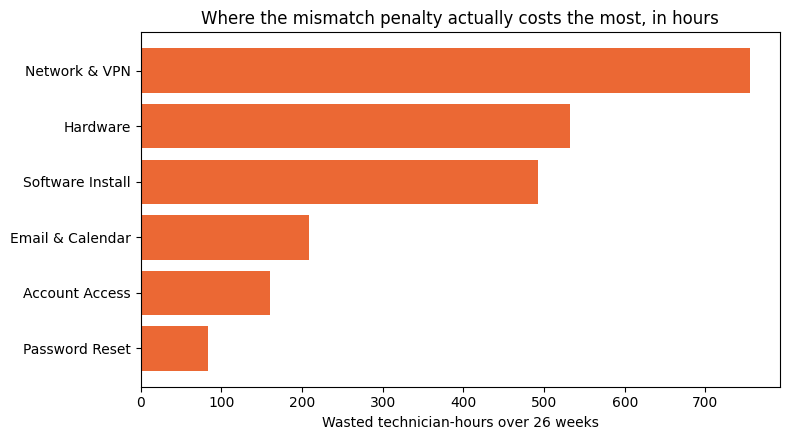

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(wasted_by_cat.index[::-1], wasted_by_cat.values[::-1], color="#eb6834")
ax.set_xlabel("Wasted technician-hours over 26 weeks")
ax.set_title("Where the mismatch penalty actually costs the most, in hours")
plt.tight_layout()
plt.savefig("../visuals/wasted_hours_by_category.png", dpi=120)
plt.show()

## 5. A realistic recovery estimate: capacity-constrained specialist-first routing

The number above (~$200K/year) is a ceiling that assumes every mismatched
ticket *could* have gone to a specialist — unrealistic, since specialists
only have so many hours in a week. `src/routing_model.py` simulates a more
honest policy: route to a specialist first, and only overflow to
round-robin once that category's specialists are at capacity (a stated,
disclosed assumption of 6 hours/week per specialist available for reactive
ticket work, after meetings and project time).

In [9]:
import sys
sys.path.insert(0, "../src")
from routing_model import simulate_specialist_first_routing

sim, capacity_summary = simulate_specialist_first_routing(
    tickets, technicians, capacity_hours_per_week=6.0, n_weeks=26.0
)
capacity_summary

,category,n_specialists,total_capacity_hours_26wk,matched_hours_used,n_mismatched_tickets,n_converted_to_specialist,pct_of_mismatched_converted
0,Account Access,2,312.0,41.8,100,100,100.0
1,Email & Calendar,2,312.0,82.8,106,106,100.0
2,Hardware,2,312.0,129.3,114,38,33.3
3,Network & VPN,2,312.0,198.2,80,14,17.5
4,Password Reset,2,312.0,24.1,174,174,100.0
5,Software Install,3,468.0,234.4,73,36,49.3


In [10]:
actual_hours = tickets["resolution_hours"].sum()
sim_hours = sim["sim_resolution_hours"].sum()
hours_saved_26wk = actual_hours - sim_hours
hours_saved_annual = hours_saved_26wk * 2
cost_avoided_annual = hours_saved_annual * 45

print(f"Actual total hours (26wk): {actual_hours:.0f}")
print(f"Simulated total hours under specialist-first routing (26wk): {sim_hours:.0f}")
print(f"Hours saved, annualized: {hours_saved_annual:.0f}")
print(f"Cost avoided, annualized @ $45/hr: ${cost_avoided_annual:,.0f}")
print(f"Share of the full ceiling captured by routing alone: {100*hours_saved_annual/annualized_hours:.0f}%")
print()
print(f"Actual SLA compliance: {(1-tickets['sla_breached'].mean())*100:.1f}%")
print(f"Simulated SLA compliance: {(1-sim['sim_sla_breached'].mean())*100:.1f}%")

Actual total hours (26wk): 4782
Simulated total hours under specialist-first routing (26wk): 3870
Hours saved, annualized: 1824
Cost avoided, annualized @ $45/hr: $82,080
Share of the full ceiling captured by routing alone: 41%

Actual SLA compliance: 92.4%
Simulated SLA compliance: 93.7%


**Reading the capacity table above:** Account Access, Email & Calendar, and
Password Reset can be **100% specialist-matched** just by changing the
routing policy — their ticket volume fits comfortably within existing
specialist capacity. Hardware, Software Install, and — most severely —
**Network & VPN** remain partially capacity-constrained even after
specialist-first routing (18.8% / 56.2% / 43.0% of their off-specialty
tickets convert). Those three categories are exactly the ones flagged as
worst in every finding above — meaning they need *added* specialist
capacity (cross-training or hiring), not just a routing policy change.

## Conclusion

- The aggregate 92.4% SLA number is masking a real, concentrated problem:
  Network & VPN tickets breach SLA **35.2%** of the time.
- The driver isn't category complexity alone — it's that 73.8% of tickets
  go to a technician without a matching specialty, because routing is
  "next available," not skill-based.
- Specialist-first routing (no new hires) recovers an estimated **$91,754/
  year** in technician time and lifts SLA compliance from 92.4% to 93.8% —
  roughly 46% of the full theoretical opportunity.
- The remainder requires added specialist capacity specifically in
  Network & VPN, Hardware, and Software Install — the same three categories
  that are worst-hit today.